### Colab Activity 12.3: Evaluation Curves – Precision vs. Recall and ROC

**Estimated Time: 90 Minutes**


This assignment focuses on using the precision-recall curves and receiver operating characteristic (ROC) curves to examine tradeoffs in classifier performance.  Also, these curves and the area they determine can be viewed as a metric itself.  Scikit-learn implements all of this, and by the end of this activity, you should be comfortable with these functions.

#### Index

- [Problem 1](#Problem-1)
- [Problem 2](#Problem-2)
- [Problem 3](#Problem-3)
- [Problem 4](#Problem-4)
- [Problem 5](#Problem-5)
- [Problem 6](#Problem-6)

Recall answers: of everyone who actually progressed to Alzheimer's, how many did the model catch?

$$\text{recall} = \frac{\text{true positives}}{\text{true positives} + \text{false negatives}} = \frac{\text{correct positive predictions}}{\text{all actual positives}}$$

Precision answers: of everyone the model flagged as "will progress to AD," how many actually did?

$$\text{precision} = \frac{\text{true positives}}{\text{true positives} + \text{false positives}} = \frac{\text{correct positive predictions}}{\text{all positive predictions}}$$





In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, precision_recall_curve, roc_curve
from sklearn.datasets import load_breast_cancer
from sklearn.compose import make_column_transformer
from sklearn import set_config

set_config(display="diagram")

### The Data


For this exercise, you will again use the credit card default data.  It is loaded and split below.  A pipeline for model building is also instantiated and fit. 

In [3]:
# 1. Load data, keep only patients with a known outcome (MCI patients)
df = pd.read_csv("../../plasma_lipidomics.csv")
mci = df[df["Progression to Alzheimer's Disease"].notna()].copy()

# 2. Fill missing numeric values with the column median
numeric_cols = ['Age', 'MMSE', 'CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)',
                 'CSF Phosphorylated tau (pg/mL)']
for col in numeric_cols:
    median_val = mci[col].median()
    mci[col] = mci[col].fillna(median_val)

# 3. Fill missing categorical values with the most common value
mode_val = mci['APOE4'].mode()[0]
mci['APOE4'] = mci['APOE4'].fillna(mode_val)

# 4. Convert categorical text columns to numeric (0/1)
mci['Sex'] = (mci['Sex'] == 'Male').astype(int)          # Male=1, Female=0
mci['APOE4'] = (mci['APOE4'] == 'Yes').astype(int)        # carries APOE4 allele=1, no=0
mci['Target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
df = mci.copy()
df = df.rename(columns={'CSF Amyloid (pg/mL)': 'amyloid', 'CSF Phosphorylated tau (pg/mL)': 'tau', "Progression to Alzheimer's Disease" : 'progression'})
numeric_cols = ['Age', 'MMSE', 'amyloid', 'CSF Total tau (pg/mL)','tau']
# 5. Final feature set + target
feature_cols = numeric_cols + ['Sex', 'APOE4']
X = df[feature_cols]
y = df['Target']

In [4]:
default = df.copy()

In [5]:
default.columns

Index(['Sample', 'Diagnostic', 'Sex', 'Age', 'MMSE', 'amyloid',
       'CSF Total tau (pg/mL)', 'tau', 'APOE4', 'progression',
       'Progression time (months)', 'Target'],
      dtype='str')

In [6]:
numeric_cols = ['Age', 'MMSE', 'amyloid', 'CSF Total tau (pg/mL)', 'tau']
categorical_cols = ['Sex', 'APOE4']  # already 0/1 encoded in cell 4

transformer = make_column_transformer(
    (StandardScaler(), numeric_cols),
    remainder='passthrough'   # lets Sex/APOE4 (already 0/1) pass through unchanged
)

X_train, X_test, y_train, y_test = train_test_split(
    df[numeric_cols + categorical_cols], df['Target'],
    stratify=df['Target'],
    random_state=42
)

knn_pipe = Pipeline([('transform', transformer), ('knn', KNeighborsClassifier(n_neighbors=10))])

In [7]:
knn_pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transform', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Age','MMSE','amyloid',...,'tau','Sex','APOE4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not sp

In [8]:
test_predictions = knn_pipe.predict_proba(X_test)

[Back to top](#-Index)

### Problem 1

#### Precision for different thresholds



Below, complete the function `precision_thresh` to take in a NumPy array of predicted probabilities and return a prediction for the positive class at or above that threshold (`thresh`) and negative prediction for the ones below.  

The function should use the `precision_score` function to return the precision score between `y_test` and `preds` with `pos_label='Yes'`.

In [9]:

def precision_thresh(predict_probs, 
                  y_test, 
                  thresh):
    preds = np.where(predict_probs >= thresh, 1, 0)
    
    return precision_score(y_test, preds, pos_label=1)


# Answer check
print(precision_thresh(test_predictions[:, 1], y_test, 0.1))
print(precision_thresh(test_predictions[:, 1], y_test, 0.9))

0.5217391304347826
1.0


[Back to top](#-Index)

### Problem 2

#### Determining precision for multiple thresholds



Now, create a DataFrame called `results_df`. This DataFrame will have a column named `threshold'` with values from the `thresholds` list. The DataFrame will also have a column named `precision`. This column should contain the precision values at each threshold calculated using the `precision_thresh` function. 



In [10]:
thresholds = np.arange(0, 1, .1)
thresholds

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [11]:

results_df = pd.DataFrame({'threshold': thresholds, 'precision': [precision_thresh(test_predictions[:, 1], y_test, i) for i in thresholds]})



# Answer check
results_df

,threshold,precision
0,0.0,0.521739
1,0.1,0.521739
2,0.2,0.523810
3,0.3,0.588235
4,0.4,0.588235
5,0.5,0.666667
6,0.6,0.818182
7,0.7,0.777778
8,0.8,0.777778
9,0.9,1.000000


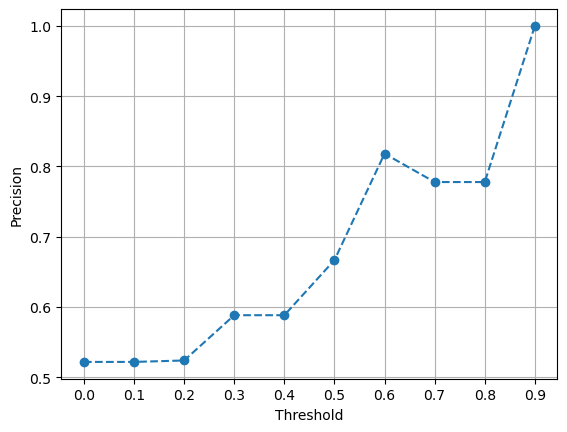

In [12]:
##Uncomment to visualize precision changes
plt.plot(results_df['threshold'], results_df['precision'], '--o', label = 'precision')
plt.xticks(thresholds)
plt.xlabel('Threshold')
plt.ylabel('Precision')
plt.grid();

[Back to top](#-Index)

### Problem 3

#### A Recall threshold function



Similar to your `precision_thresh` function, complete the function `recall_thresh` below to compute the recall given a threshold.  Your function should use the `recall_score` function to return the recall score between `y_test` and `preds` with `pos_label='Yes'`.


Inside the `result_df` DataFrame, add a column called `recall`. This column should contain the recall values at each threshold calculated using the `recall_thresh` function. 

In [13]:

def recall_thresh(predict_probs, 
                  y_test, 
                  thresh):
    preds = np.where(predict_probs >= thresh, 1, 0)
    
    return recall_score(y_test, preds, pos_label=1)
results_df['recall'] = [recall_thresh(test_predictions[:, 1], y_test, i) for i in thresholds]


# Answer check
print(recall_thresh(test_predictions[:, 1], y_test, 0.1))
print(recall_thresh(test_predictions[:, 1], y_test, 0.9))
results_df

1.0
0.25


,threshold,precision,recall
0,0.0,0.521739,1.000000
1,0.1,0.521739,1.000000
2,0.2,0.523810,0.916667
3,0.3,0.588235,0.833333
4,0.4,0.588235,0.833333
5,0.5,0.666667,0.833333
6,0.6,0.818182,0.750000
7,0.7,0.777778,0.583333
8,0.8,0.777778,0.583333
9,0.9,1.000000,0.250000


[Back to top](#-Index)

### Problem 4

#### Precision vs. Recall Tradeoff


As you see in the plot below based, on the `results_df`, improving the precision involves a decrease in recall.  

<center>
    <img src = 'images/precall.png'/>
</center>

scikit learn implements a function `precision_recall_curve` that takes as arguments `y_true`, `probas_pred`, `pos_label=None`. 

The function returns the values for precision, recall, and the decision thresholds.  Use the probabilities in `test_predictions` in the `precision_recall_curve` function, and assign the results to `precision`, `recall`, and `boundaries` below.  Uncomment the plot to visualize your results.

[0.1 0.2 0.3 0.4 0.5]


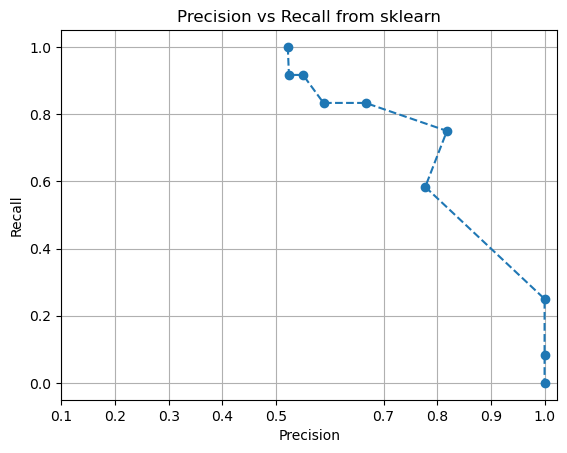

In [14]:

precision, recall, boundaries = precision_recall_curve(y_test, test_predictions[:, 1], pos_label=1)


# Answer check
print(boundaries[:5])
plt.plot(precision, recall, '--o')
plt.xticks(boundaries);
plt.grid()
plt.ylabel('Recall')
plt.xlabel('Precision')
plt.title('Precision vs Recall from sklearn');

[Back to top](#-Index)

### Problem 5

#### ROC Curve



Similar to the `precision_recall_curve`, the `roc_curve` function takes in `y_true` and `y_score`, which can be predicted probabilities.  The function returns the false positive rates, true positive rates, and thresholds.  Assign these to `fpr`, `tpr`, and `thresh_rocs` below.  Uncomment the code to visualize the ROC curve. 

False Positive Rates:  [0.         0.         0.         0.18181818 0.18181818]
True Positive Rates:  [0.         0.08333333 0.25       0.58333333 0.75      ]


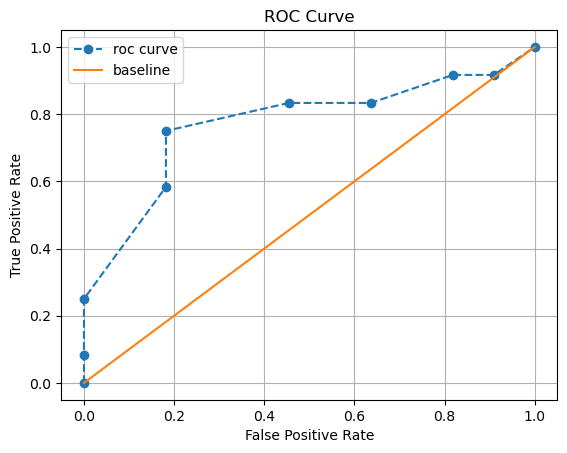

In [15]:

fpr, tpr, thresh_rocs = roc_curve(y_test, test_predictions[:, 1], pos_label=1)


# Answer check
print('False Positive Rates: ', fpr[:5])
print('True Positive Rates: ', tpr[:5])
plt.plot(fpr, tpr, '--o', label = 'roc curve')
plt.plot(tpr, tpr, label = 'baseline')
plt.legend()
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.grid();

[Back to top](#-Index)

### Problem 6

#### Area Under Curve as metric



Finally, consider the proposed area under the curve scoring method described in the lectures.  Below, construct a grid search named `roc_grid` that uses the `knn_pipe` and searches over the number of neighbors from 1 to 31 by odd values, choosing the model that optimizes `roc_auc_score`.  Identify the optimal number of neighbors and assign them to `best_k` below.  

In [16]:

roc_grid = GridSearchCV(knn_pipe, param_grid={'knn__n_neighbors': range(1, 33, 2)}, scoring = 'roc_auc')
roc_grid.fit(X_train, y_train)
best_k = roc_grid.best_params_['knn__n_neighbors']


# Answer check
best_k

3

#### Visualizing with scikitlearn

Below, we use the `RocCurveDisplay` to display roc curves for three knn models.  You can either use predictions or estimators to create the visualization.  Below, we use the `from_estimator` method.

In [17]:
from sklearn.metrics import RocCurveDisplay

In [18]:
knn_1 = Pipeline([('transform', transformer), ('knn', KNeighborsClassifier(n_neighbors = 1))])
knn_1.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('transform', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Age','MMSE','amyloid',...,'tau','Sex','APOE4']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('standardscaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not sp

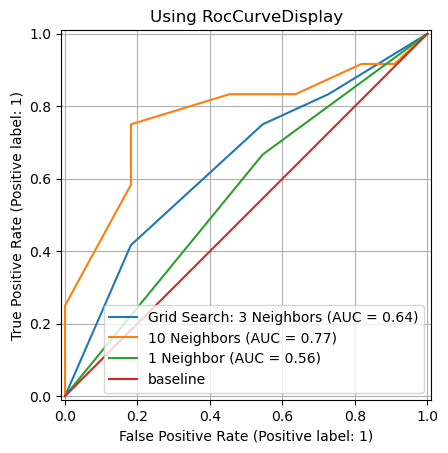

In [19]:
fig, ax = plt.subplots()
RocCurveDisplay.from_estimator(roc_grid, X_test, y_test, pos_label=1, ax=ax, name=f'Grid Search: {best_k} Neighbors')
RocCurveDisplay.from_estimator(knn_pipe, X_test, y_test, pos_label=1, ax=ax, name='10 Neighbors')
RocCurveDisplay.from_estimator(knn_1, X_test, y_test, ax=ax, name='1 Neighbor')
plt.grid()
plt.plot(np.arange(0, 1.1, .1), np.arange(0, 1.1, .1), label='baseline')
plt.title('Using RocCurveDisplay')
plt.legend()